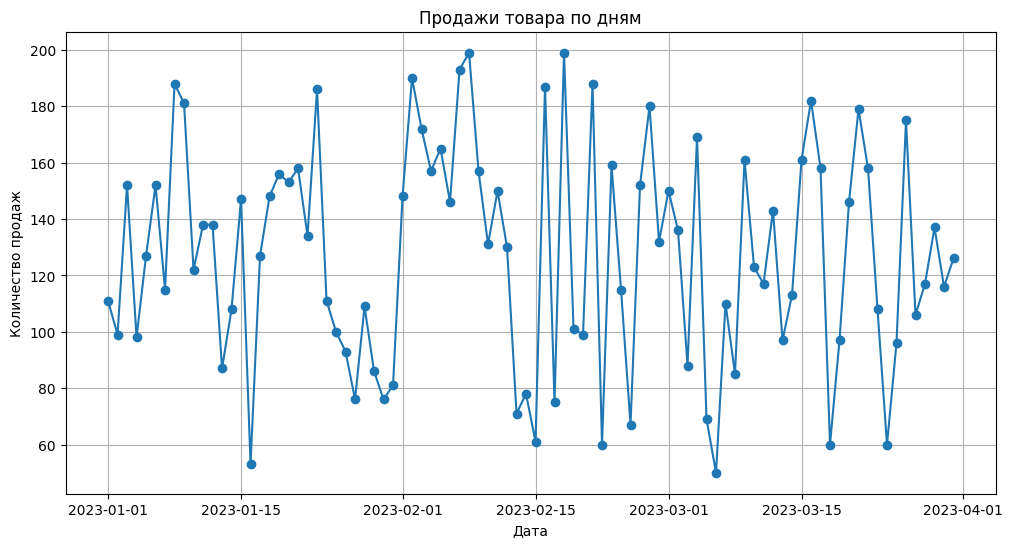

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Создаём даты с 1 января 2023 по 31 марта 2023 с шагом 1 день
dates = pd.date_range(start='2023-01-01', end='2023-03-31', freq='D')

# Генерируем случайные данные, например, продажи товара
sales = np.random.randint(50, 200, size=len(dates))

# Создаём DataFrame с датами и значениями
df = pd.DataFrame({'Дата': dates, 'Продажи': sales})

# Устанавливаем колонку 'Дата' как индекс для удобства работы с временным рядом
df.set_index('Дата', inplace=True)

# Строим график временного ряда
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Продажи'], marker='o', linestyle='-')
plt.title('Продажи товара по дням')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.show()

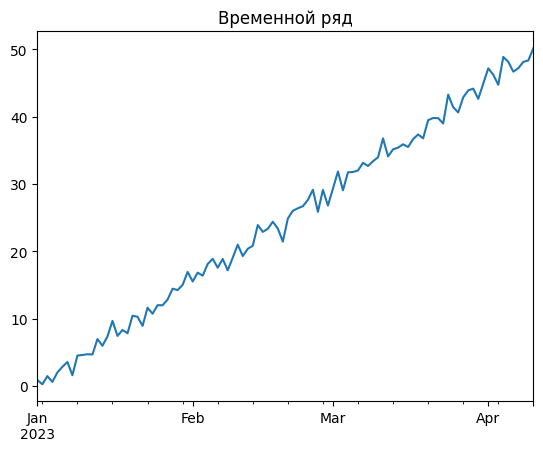

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -183.228
Date:                Fri, 18 Apr 2025   AIC                            372.455
Time:                        18:27:09   BIC                            380.240
Sample:                    01-01-2023   HQIC                           375.605
                         - 04-10-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2290      0.301     -0.760      0.447      -0.820       0.362
ma.L1         -0.1705      0.327     -0.521      0.602      -0.812       0.471
sigma2         2.3681      0.371      6.385      0.0

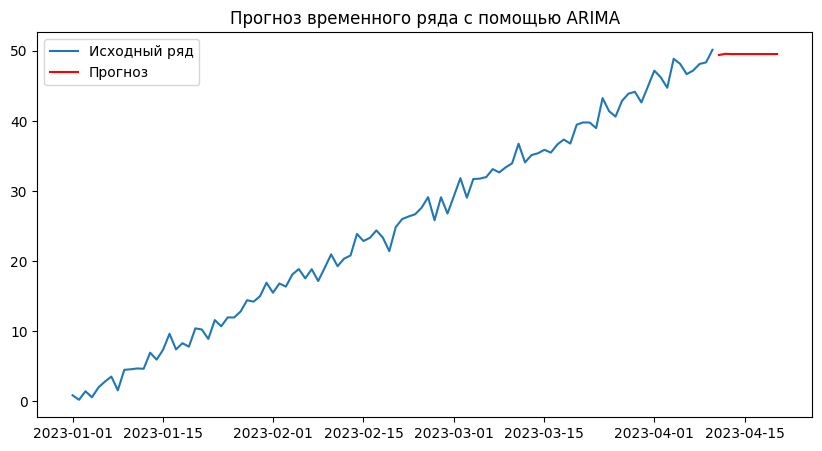

In [ ]:
# ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Создаём искусственный временной ряд (например, тренд + шум)
np.random.seed(4132)
n = 100
time = np.arange(n)
data = 0.5 * time + np.random.normal(size=n)

# Преобразуем в pandas Series с индексом-датой
dates = pd.date_range(start='2023-01-01', periods=n, freq='D')
ts = pd.Series(data, index=dates)

# Строим график исходного ряда
ts.plot(title='Временной ряд')
plt.show()

# Создаём и обучаем модель ARIMA(p=1, d=1, q=1)
model = ARIMA(ts, order=(1, 1, 1))
model_fit = model.fit()

# Выводим краткую сводку по модели
print(model_fit.summary())

# Прогнозируем следующие 10 значений
forecast = model_fit.forecast(steps=10)

# Визуализируем исходный ряд и прогноз
plt.figure(figsize=(10,5))
plt.plot(ts, label='Исходный ряд')
plt.plot(forecast.index, forecast, label='Прогноз', color='red')
plt.legend()
plt.title('Прогноз временного ряда с помощью ARIMA')
plt.show()

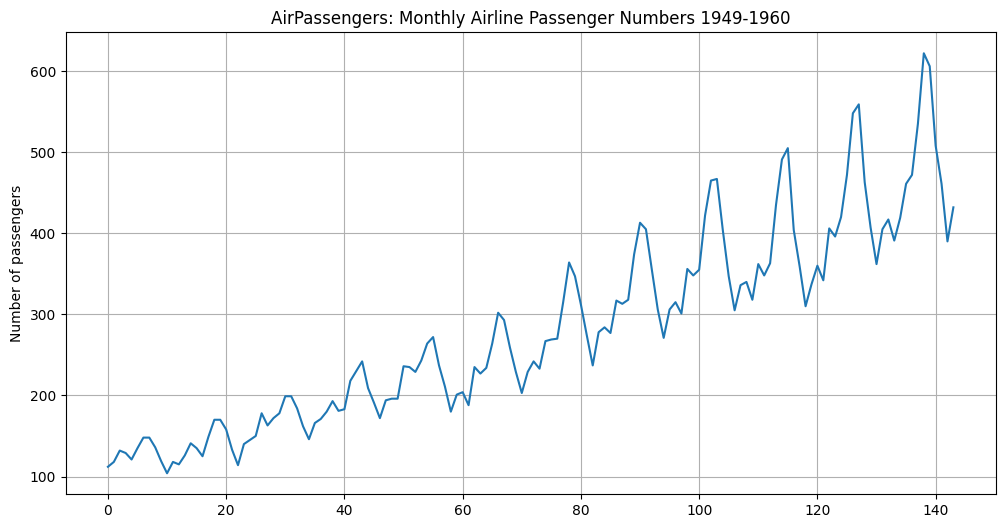

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import statsmodels.api as sm
data = sm.datasets.get_rdataset("AirPassengers", "datasets")
ts = data.data['value']


# Визуализация временного ряда
plt.figure(figsize=(12,6))
plt.plot(ts)
plt.title('AirPassengers: Monthly Airline Passenger Numbers 1949-1960')
plt.ylabel('Number of passengers')
plt.grid(True)
plt.show()


In [5]:
def test_stationarity(timeseries):
    dftest = adfuller(timeseries)
    print(f'ADF Statistic: {dftest[0]:.4f}')
    print(f'p-value: {dftest[1]:.4f}')
    for key, value in dftest[4].items():
        print(f'Critical Value {key}: {value:.4f}')
    if dftest[1] < 0.05:
        print("Ряд стационарен")
    else:
        print("Ряд нестационарен")

test_stationarity(ts)


ADF Statistic: 0.8154
p-value: 0.9919
Critical Value 1%: -3.4817
Critical Value 5%: -2.8840
Critical Value 10%: -2.5788
Ряд нестационарен


In [9]:
ts_diff = ts.diff().dropna()
test_stationarity(ts_diff)

ts_season_diff = ts.diff(12).dropna()
test_stationarity(ts_season_diff)


ADF Statistic: -2.8293
p-value: 0.0542
Critical Value 1%: -3.4817
Critical Value 5%: -2.8840
Critical Value 10%: -2.5788
Ряд нестационарен
ADF Statistic: -3.3830
p-value: 0.0116
Critical Value 1%: -3.4817
Critical Value 5%: -2.8840
Critical Value 10%: -2.5788
Ряд стационарен


<Figure size 1200x500 with 0 Axes>

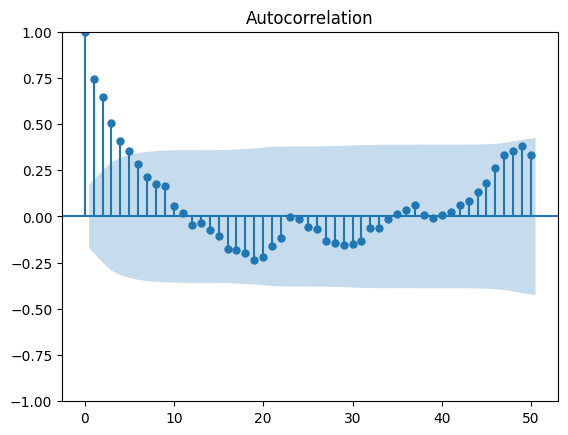

<Figure size 1200x500 with 0 Axes>

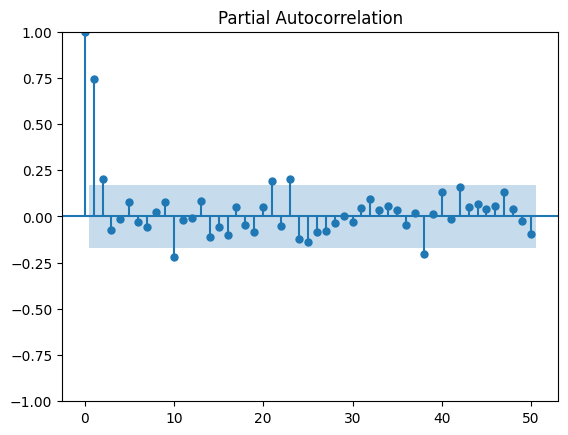

In [10]:
plt.figure(figsize=(12,5))
plot_acf(ts_season_diff, lags=50)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(ts_season_diff, lags=50)
plt.show()


In [11]:
model = SARIMAX(ts, order=(0,1,1), seasonal_order=(0,1,1,12))
model_fit = model.fit(disp=False)
print(model_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -507.501
Date:                            Tue, 10 Jun 2025   AIC                           1021.003
Time:                                    09:12:19   BIC                           1029.628
Sample:                                         0   HQIC                          1024.507
                                            - 144                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3087      0.068     -4.507      0.000      -0.443      -0.174
ma.S.L12      -0.1075      0.091   

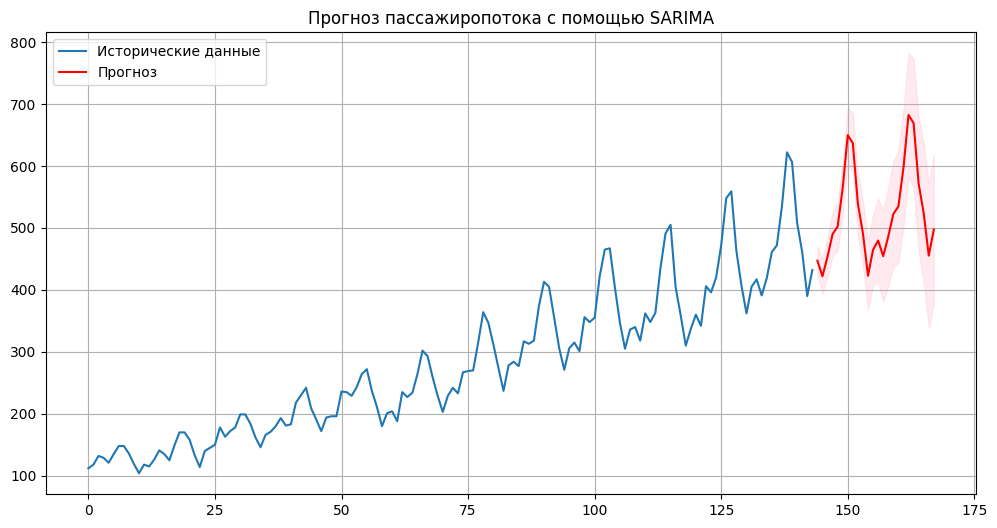

In [12]:
forecast_steps = 24
forecast = model_fit.get_forecast(steps=forecast_steps)
mean_forecast = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure(figsize=(12,6))
plt.plot(ts, label='Исторические данные')
plt.plot(mean_forecast.index, mean_forecast, color='red', label='Прогноз')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title('Прогноз пассажиропотока с помощью SARIMA')
plt.legend()
plt.grid(True)
plt.show()


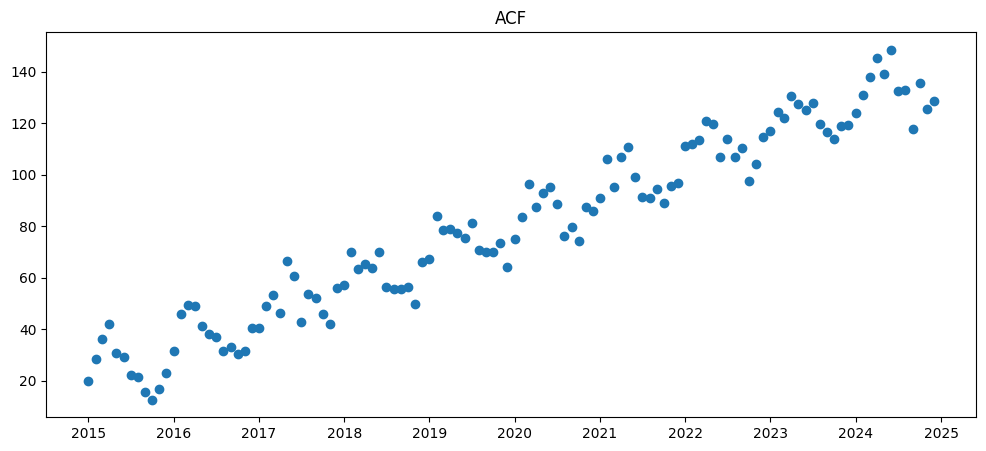

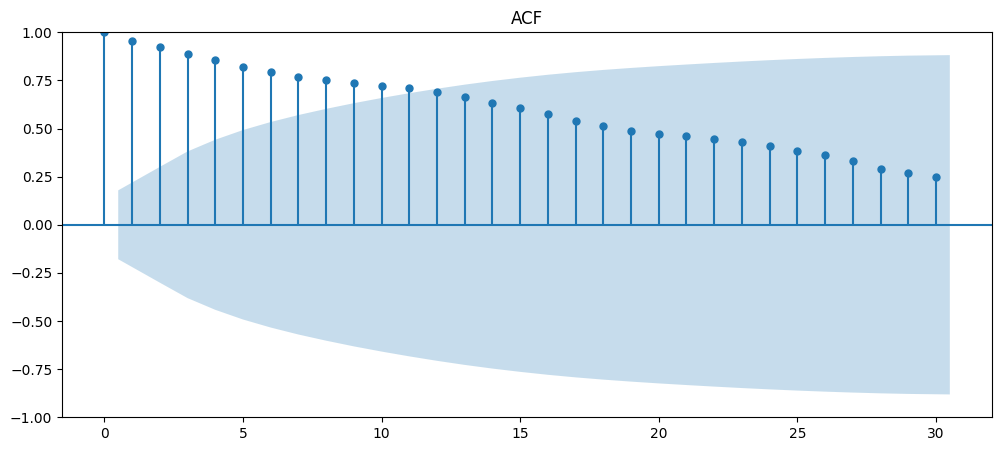

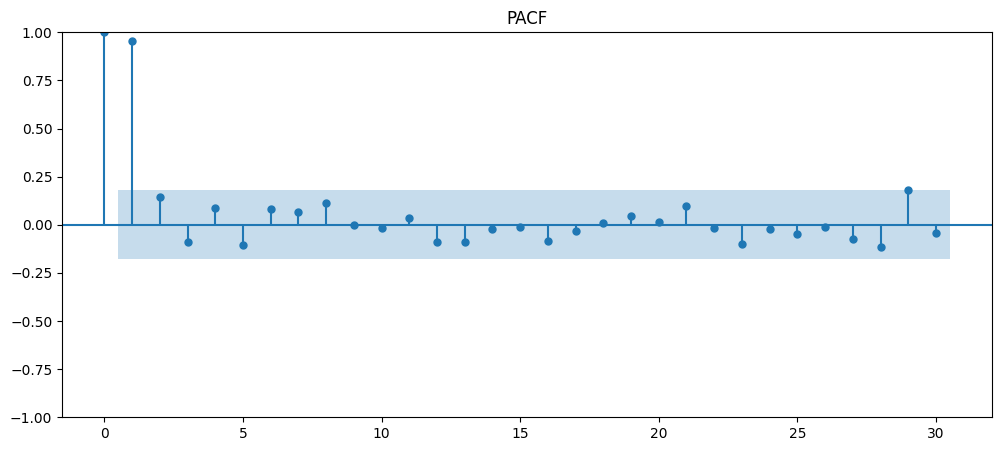

In [19]:
# Пример
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Создадим пример временного ряда (с сезонностью)
dates = pd.date_range(start='2015-01-01', end='2024-12-01', freq='MS')
values = [20 + i + 10*np.sin(i*np.pi/6) + 5*np.random.randn() for i in range(len(dates))]
ts = pd.Series(values, index=dates)

plt.figure(figsize=(12, 5))
plt.scatter(dates, values)
plt.title('ACF')
plt.show()

# Построим графики ACF и PACF
plt.figure(figsize=(12, 5))
plot_acf(ts, lags=30, ax=plt.gca())
plt.title('ACF')
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(ts, lags=30, ax=plt.gca(), method='ywm')
plt.title('PACF')
plt.show()


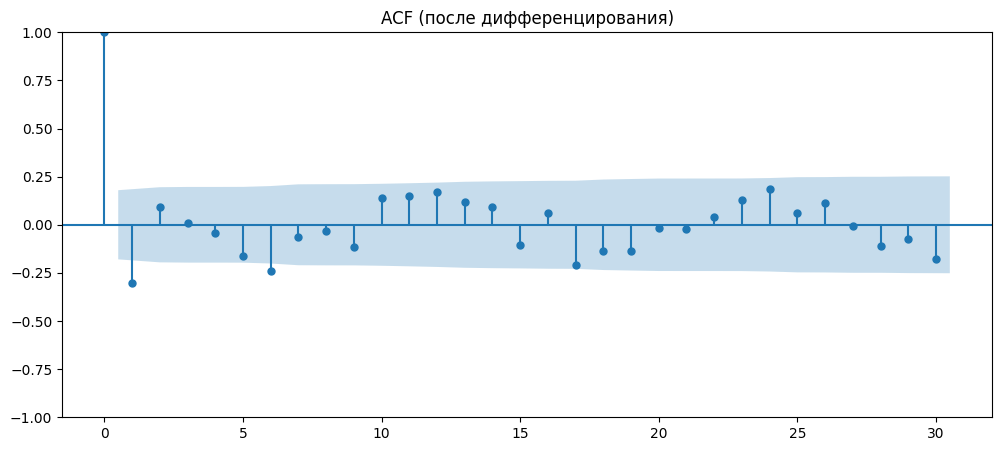

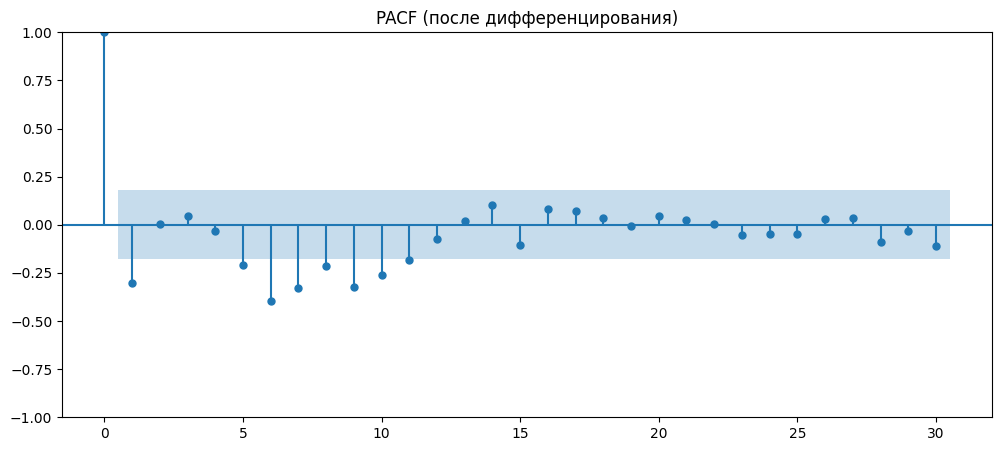

In [16]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(12, 5))
plot_acf(ts_diff, lags=30, ax=plt.gca())
plt.title('ACF (после дифференцирования)')
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(ts_diff, lags=30, ax=plt.gca(), method='ywm')
plt.title('PACF (после дифференцирования)')
plt.show()
